# trajkit × Geolife — visual validation

Runs the full trajkit pipeline on one Geolife user, then visualises the
results so you can judge whether the segmentation, episode detection,
and similarity search produce sensible output on real-world GPS.

**What you should look for:**

- Segment colours on the map should match physical activity:
  long blue stretches on roads (`MOVE`), red dots at homes/offices
  (`STOP_DWELL`), orange clusters at building entrances (`MOVE_BRIEF`).
- STAY anchors should land at obvious recurring places (home, work,
  transit hubs).
- The histogram tails should look like real-world activity, not
  synthetic noise.
- Similarity search should return geographically + behaviourally
  plausible matches.

## Setup

In [1]:
from pathlib import Path
import os
import sys
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure the local Geolife reader is importable
sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, "examples/geolife")
from reader import read_user  # noqa: E402

from trajkit.compare import build_index, search  # noqa: E402
from trajkit.runner import RunParams, process  # noqa: E402

GEOLIFE_DATA = Path(os.path.expanduser("~/.cache/trajkit/Geolife Trajectories 1.3/Data"))
USER_ID = "000"
TIME_WINDOW_DAYS = 7  # keep the map and run tractable

## 1. Load Geolife user

Microsoft Geolife user `000` has ~174K pings spanning multiple years.
We slice a one-week window so the map stays interactive.

In [2]:
all_pings = read_user(GEOLIFE_DATA / USER_ID, entity_id=USER_ID)
print(f"User {USER_ID}: {len(all_pings):,} pings spanning "
      f"{all_pings['ts'].min().date()} → {all_pings['ts'].max().date()}")

# Find the most active 7-day window
day_counts = all_pings["ts"].dt.floor("D").value_counts().sort_values(ascending=False)
busiest_day = day_counts.index[0]
window_start = busiest_day - pd.Timedelta(days=TIME_WINDOW_DAYS // 2)
window_end = window_start + pd.Timedelta(days=TIME_WINDOW_DAYS)
mask = (all_pings["ts"] >= window_start) & (all_pings["ts"] < window_end)
pings = all_pings.loc[mask].reset_index(drop=True)
print(f"Window: {window_start.date()} → {window_end.date()}  "
      f"({len(pings):,} pings)")

User 000: 173,870 pings spanning 2008-10-23 → 2009-07-05
Window: 2009-03-31 → 2009-04-07  (23,603 pings)


## 2. Run the trajkit pipeline

Pedestrian preset (`R_m=30 m`, `T_s=120 s`, `min_stay_s=120 s`) — the
v0.1.0 published preset for walking-scale data.

In [3]:
sink = Path("/tmp/trajkit_geolife_explore")
if sink.exists():
    import shutil
    shutil.rmtree(sink)
params = RunParams.from_preset("pedestrian")
report = process(pings, sink, params, n_workers=1)
print(f"succeeded={report.succeeded}  elapsed={report.elapsed_seconds:.1f}s")

succeeded=True  elapsed=0.5s


## 3. Read pipeline outputs

In [4]:
segments = pd.read_parquet(sink / "segment" / f"entity_id={USER_ID}" / "data.parquet")
episodes = pd.read_parquet(sink / "episode" / f"entity_id={USER_ID}" / "data.parquet")
seg_vectors_df = pd.read_parquet(
    sink / "embed_segments" / f"entity_id={USER_ID}" / "data.parquet"
)
print(f"Segments: {len(segments):,}")
print(f"Episodes: {len(episodes):,} "
      f"(STAY={(episodes['episode_type']=='STAY').sum()}, "
      f"TRANSIT={(episodes['episode_type']=='TRANSIT').sum()})")
print(f"Segment vectors: {len(seg_vectors_df)} × "
      f"{len(np.asarray(seg_vectors_df['vector'].iloc[0]))} dims")

Segments: 781
Episodes: 192 (STAY=101, TRANSIT=91)
Segment vectors: 781 × 32 dims


## 4. Segment-type breakdown

A pedestrian's day mixes movement and stops. Expect substantial
fractions of `MOVE` and `STOP_BRIEF`, fewer `STOP_DWELL` (long stops
at home/work) and `MOVE_BRIEF` (yard-shuffle-equivalents).

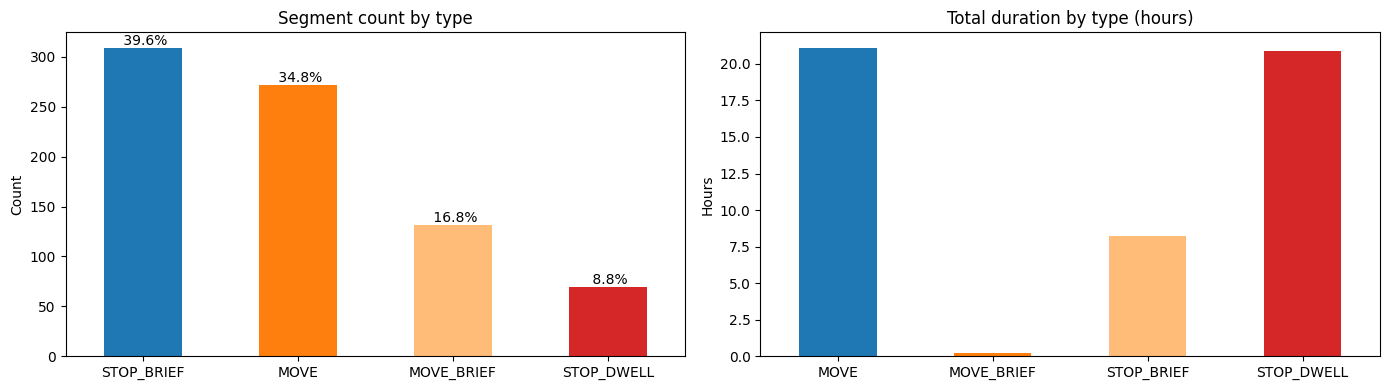

In [5]:
type_counts = segments["segment_type"].value_counts()
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
type_counts.plot.bar(ax=ax[0], color=["#1f77b4", "#ff7f0e", "#ffbb78", "#d62728"])
ax[0].set_title("Segment count by type")
ax[0].set_ylabel("Count")
ax[0].set_xlabel("")
ax[0].tick_params(axis="x", rotation=0)
fractions = (type_counts / type_counts.sum() * 100).round(1)
for i, (label, frac) in enumerate(zip(type_counts.index, fractions)):
    ax[0].text(i, type_counts.iloc[i], f" {frac}%", ha="center", va="bottom")
type_total_duration = segments.groupby("segment_type")["duration_s"].sum() / 3600
type_total_duration.plot.bar(ax=ax[1], color=["#1f77b4", "#ff7f0e", "#ffbb78", "#d62728"])
ax[1].set_title("Total duration by type (hours)")
ax[1].set_ylabel("Hours")
ax[1].set_xlabel("")
ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

**Reading guide.** The count chart shows how many *atomic episodes*
fall in each bucket. The duration chart shows how the user *spent
their time*. STOP_DWELL count is small but its duration share is
usually large (sleeping at home dominates).

## 5. Stay duration distribution

A real person's stays span a wide range: 5-min coffee stops, hour-long
meetings, overnight rests. A log-scale distribution should show that
multi-modal shape.

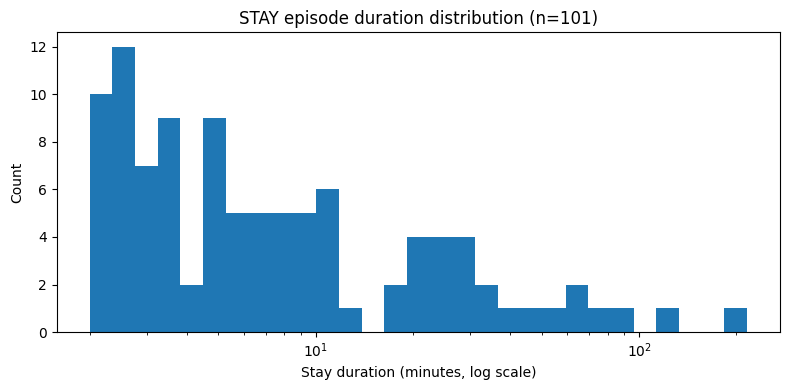

In [6]:
stay_minutes = episodes.loc[episodes["episode_type"] == "STAY", "duration_s"] / 60.0
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(stay_minutes, bins=np.logspace(np.log10(2), np.log10(stay_minutes.max() + 1), 30))
ax.set_xscale("log")
ax.set_xlabel("Stay duration (minutes, log scale)")
ax.set_ylabel("Count")
ax.set_title(f"STAY episode duration distribution (n={len(stay_minutes)})")
plt.tight_layout()
plt.show()

**Reading guide.** Look for distinct peaks: short stops (5-30 min:
transit, errands), medium stops (1-3 hrs: meetings, meals),
long stops (8+ hrs: sleep at home). If you see only one big peak,
something is collapsing distinct stay types into one — check the
`R_m` parameter.

## 6. Map: segments color-coded by type

Each polyline is one segment. Colour encodes `segment_type`. Click a
segment to see its summary.

In [7]:
COLOUR = {
    "MOVE": "#1f77b4",
    "MOVE_BRIEF": "#ff7f0e",
    "STOP_BRIEF": "#ffbb78",
    "STOP_DWELL": "#d62728",
}

# Centre the map on the median position of the window
center_lat = float(pings["lat"].median())
center_lon = float(pings["lon"].median())
m_segments = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles="cartodbpositron")

# The runner persists per-segment aggregated frames (one row per segment),
# not the per-ping intermediate. So we draw straight lines start→end for
# each segment — sufficient for visual segmentation validation since
# segment-level kinematics dominate the appearance.
for _, seg in segments.sort_values("start_ts").iterrows():
    folium.PolyLine(
        locations=[(seg["start_lat"], seg["start_lon"]), (seg["end_lat"], seg["end_lon"])],
        color=COLOUR[seg["segment_type"]],
        weight=3 if seg["segment_type"].startswith("MOVE") else 5,
        opacity=0.6,
        tooltip=(
            f"{seg['segment_type']} • {seg['duration_s']:.0f}s • "
            f"{seg['displacement_m']:.0f}m"
        ),
    ).add_to(m_segments)

# Legend
legend_html = """
<div style='position: fixed; top:10px; right:10px; z-index:9999;
            background:white; padding:8px; border:1px solid #888; font-size:13px;'>
  <b>Segment type</b><br>
  <span style='color:#1f77b4'>━━━</span> MOVE<br>
  <span style='color:#ff7f0e'>━━━</span> MOVE_BRIEF<br>
  <span style='color:#ffbb78'>━━━</span> STOP_BRIEF<br>
  <span style='color:#d62728'>━━━</span> STOP_DWELL<br>
</div>
"""
m_segments.get_root().html.add_child(folium.Element(legend_html))
m_segments.save("segments_map.html")
m_segments

## 7. Map: STAY anchors

Each marker is one STAY episode, sized roughly by its duration.
Recurring places (home, work, frequented venues) appear as marker
clusters at the same location.

In [8]:
stays = episodes[episodes["episode_type"] == "STAY"].copy()
m_stays = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles="cartodbpositron")
for _, ep in stays.iterrows():
    duration_min = float(ep["duration_s"]) / 60.0
    radius = float(np.clip(np.log1p(duration_min) * 2.5, 4, 25))
    folium.CircleMarker(
        location=[float(ep["anchor_lat"]), float(ep["anchor_lon"])],
        radius=radius,
        color="#d62728",
        fill=True,
        fill_opacity=0.5,
        tooltip=(
            f"{duration_min:.1f} min • envelope_radius={ep['envelope_radius_m']:.1f} m"
        ),
    ).add_to(m_stays)
m_stays.save("stays_map.html")
m_stays

**Reading guide.** Look for marker clusters at obvious recurring
places (the user's home, workplace, restaurants). If you see only
scattered, never-repeated stays, the algorithm isn't recognising
repeated visits → check that the H3 anchor resolution and `R_m` are
appropriate for pedestrian data.

## 8. Similarity search

Pick a `MOVE` segment near the centre of the trace and find its top-5
nearest neighbours by cosine similarity over the 32-dim base
embedding. The neighbours should be plausibly similar movements.

In [9]:
vectors = np.vstack(
    [np.asarray(v, dtype=np.float32) for v in seg_vectors_df["vector"]]
)
ids = seg_vectors_df["id"].astype(str).tolist()
move_mask = segments["segment_type"] == "MOVE"
query_seg_id = segments.loc[move_mask, "segment_id"].iloc[len(segments[move_mask]) // 2]
query_idx = ids.index(query_seg_id)

index = build_index(vectors, ids, metric="cosine")
hits = search(index, vectors[query_idx], k=6)
print(f"Query: {query_seg_id}")
hits_table = pd.DataFrame(
    [{"rank": h.rank, "id": h.id, "score": h.score} for h in hits]
)
hits_table = hits_table.merge(
    segments[["segment_id", "segment_type", "duration_s", "displacement_m",
              "start_lat", "start_lon"]],
    left_on="id",
    right_on="segment_id",
)
print(hits_table[["rank", "id", "score", "segment_type", "duration_s", "displacement_m"]])

# Plot the query and its neighbours on a map
m_sim = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles="cartodbpositron")
for _, row in hits_table.iterrows():
    seg_row = segments.loc[segments["segment_id"] == row["id"]].iloc[0]
    is_query = (row["rank"] == 0)
    colour = "#000000" if is_query else "#1f77b4"
    folium.PolyLine(
        locations=[(seg_row["start_lat"], seg_row["start_lon"]),
                   (seg_row["end_lat"], seg_row["end_lon"])],
        color=colour,
        weight=6 if is_query else 3,
        opacity=0.9 if is_query else 0.6,
        tooltip=(
            f"rank={row['rank']} score={row['score']:.4f} "
            f"{seg_row['segment_type']}"
        ),
    ).add_to(m_sim)
m_sim.save("similarity_map.html")
m_sim

Query: 000_seg_00384
   rank             id     score segment_type  duration_s  displacement_m
0     0  000_seg_00384  1.000000         MOVE        35.0       23.262911
1     1  000_seg_00376  0.986127         MOVE        40.0       36.287502
2     2  000_seg_00394  0.985729         MOVE        20.0        5.217750
3     3  000_seg_00398  0.985715         MOVE        40.0       20.882153
4     4  000_seg_00374  0.978955         MOVE        25.0        7.690305
5     5  000_seg_00378  0.978836         MOVE       125.0       16.181921


**Reading guide.** The query (black, rank 0) is one MOVE segment.
The blue neighbours are the top similarity matches. They should look
plausibly similar in *something* — duration, displacement, time of
day, neighbourhood — not arbitrary geographic proximity.

## What we learned

This is the human-validation step. Things to check:

1. Do the segment colours on the trajectory map track physical
   activity? Long roads should be `MOVE`, parking lots / building
   entrances should be `MOVE_BRIEF` + `STOP_BRIEF`.
2. Do STAY markers cluster at recurring places? If user 000 lives in
   Beijing, you should see a tight cluster at one residential location.
3. Does the stay-duration histogram have multi-modal structure
   (short / medium / long stops)? Or is it one big lump?
4. Are the similarity hits plausible? A rush-hour commute query
   should not return weekend leisurely walks.

Each "no" answer is a concrete tuning lead. Each "yes" is real
validation that beats unit-test green.